# IDS — Классификатор сетевых вторжений
## EDA + Обучение и сравнение моделей

**Датасет:** NSL-KDD  
**Задача:** Бинарная классификация — `normal` (0) vs `attack` (1)  
**Метрика:** F1-score (weighted), ROC-AUC

---

### Содержание
1. [Загрузка данных](#1)
2. [Первичный анализ (EDA)](#2)
3. [Распределение классов](#3)
4. [Анализ признаков](#4)
5. [Предобработка](#5)
6. [Обучение моделей](#6)
7. [Сравнение моделей](#7)
8. [Финальная модель: XGBoost](#8)
9. [Выводы](#9)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
import os
import yaml

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Запускаем из папки project/
os.chdir('/Users/reginasadykova/Downloads/project')  

print('✅ Библиотеки загружены')

✅ Библиотеки загружены


<a id='1'></a>
## 1. Загрузка данных

In [26]:
with open('configs/config.yaml', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

columns = cfg['data']['columns']

df_train = pd.read_csv('data/KDDTrain+.csv', header=None, names=columns)
df_test  = pd.read_csv('data/KDDTest+.csv',  header=None, names=columns)

print(f'Train: {df_train.shape[0]:,} строк, {df_train.shape[1]} столбцов')
print(f'Test:  {df_test.shape[0]:,} строк,  {df_test.shape[1]} столбцов')

df_train.head(3)

Train: 125,973 строк, 43 столбцов
Test:  22,544 строк,  43 столбцов


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19


<a id='2'></a>
## 2. Первичный анализ (EDA)

In [27]:
print('=== Типы данных ===')
print(df_train.dtypes.value_counts())
print()
print('=== Пропущенные значения ===')
print(df_train.isnull().sum().sum(), '— пропусков нет')
print()
print('=== Уникальные значения меток ===')
print(df_train['label'].nunique(), 'уникальных типов трафика')
print(df_train['label'].value_counts().head(10))

=== Типы данных ===
int64      24
float64    15
str         4
Name: count, dtype: int64

=== Пропущенные значения ===
0 — пропусков нет

=== Уникальные значения меток ===
23 уникальных типов трафика
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


In [28]:
# Статистика числовых признаков
df_train.describe().round(2)

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00,1.259730e+05,1.259730e+05,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,...,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00,125973.00
mean,287.14,4.556674e+04,1.977911e+04,0.00,0.02,0.00,0.20,0.00,0.40,0.28,...,115.65,0.52,0.08,0.15,0.03,0.28,0.28,0.12,0.12,19.50
std,2604.52,5.870331e+06,4.021269e+06,0.01,0.25,0.01,2.15,0.05,0.49,23.94,...,110.70,0.45,0.19,0.31,0.11,0.44,0.45,0.31,0.32,2.29
min,0.00,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,10.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.00
50%,0.00,4.400000e+01,0.000000e+00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,63.00,0.51,0.02,0.00,0.00,0.00,0.00,0.00,0.00,20.00
75%,0.00,2.760000e+02,5.160000e+02,0.00,0.00,0.00,0.00,0.00,1.00,0.00,...,255.00,1.00,0.07,0.06,0.02,1.00,1.00,0.00,0.00,21.00
max,42908.00,1.379964e+09,1.309937e+09,1.00,3.00,3.00,77.00,5.00,1.00,7479.00,...,255.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,21.00


<a id='3'></a>
## 3. Распределение классов

Бинарная метка: `normal` → 0, любая атака → 1

In [29]:
# Создаём бинарную метку
df_train['binary_label'] = (df_train['label'] != 'normal').astype(int)
df_test['binary_label']  = (df_test['label']  != 'normal').astype(int)

print('Train:')
print(f"  normal: {(df_train['binary_label']==0).sum():,} ({(df_train['binary_label']==0).mean()*100:.1f}%)")
print(f"  attack: {(df_train['binary_label']==1).sum():,} ({(df_train['binary_label']==1).mean()*100:.1f}%)")
print('Test:')
print(f"  normal: {(df_test['binary_label']==0).sum():,} ({(df_test['binary_label']==0).mean()*100:.1f}%)")
print(f"  attack: {(df_test['binary_label']==1).sum():,} ({(df_test['binary_label']==1).mean()*100:.1f}%)")

Train:
  normal: 67,343 (53.5%)
  attack: 58,630 (46.5%)
Test:
  normal: 9,711 (43.1%)
  attack: 12,833 (56.9%)


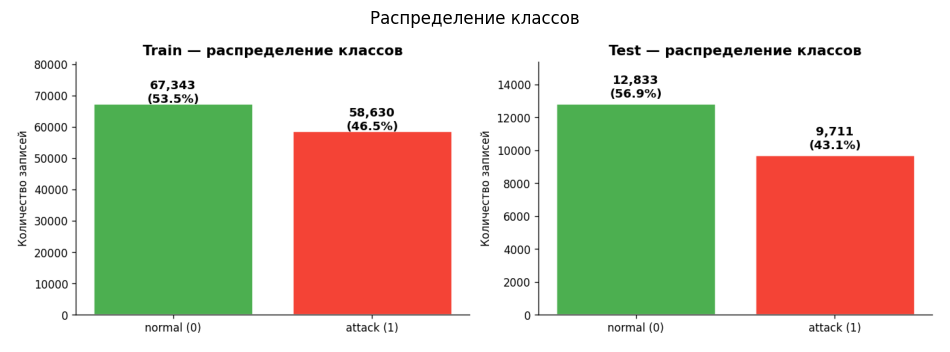

Вывод: дисбаланс умеренный (~43% normal / ~57% attack) — специальных техник не требует.


In [30]:
img = mpimg.imread('/Users/reginasadykova/Downloads/project 3/notebooks/img/01_class_distribution.png')
plt.figure(figsize=(12, 4))
plt.imshow(img); plt.axis('off')
plt.title('Распределение классов', pad=10)
plt.show()
print('Вывод: дисбаланс умеренный (~43% normal / ~57% attack) — специальных техник не требует.')

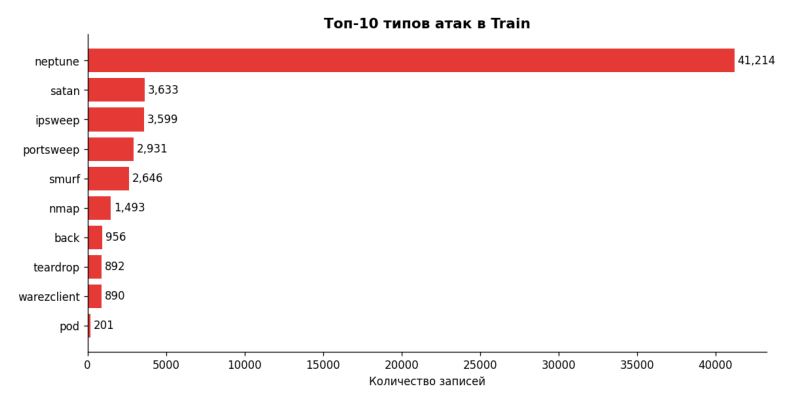

Вывод: доминируют DoS-атаки (neptune, smurf). R2L/U2R редки — это объясняет сложность их классификации.


In [31]:
img = mpimg.imread('/Users/reginasadykova/Downloads/project 3/notebooks/img/02_top_attacks.png')
plt.figure(figsize=(10, 5))
plt.imshow(img); plt.axis('off')
plt.show()
print('Вывод: доминируют DoS-атаки (neptune, smurf). R2L/U2R редки — это объясняет сложность их классификации.')

<a id='4'></a>
## 4. Анализ признаков

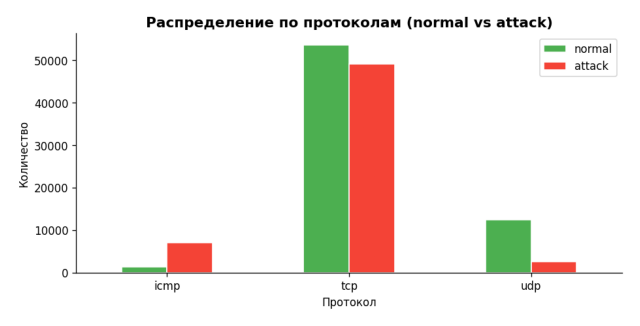

Вывод: icmp почти полностью состоит из атак — сильный предиктор.


In [32]:
img = mpimg.imread('/Users/reginasadykova/Downloads/project 3/notebooks/img/03_protocol_distribution.png')
plt.figure(figsize=(8, 4))
plt.imshow(img); plt.axis('off')
plt.show()
print('Вывод: icmp почти полностью состоит из атак — сильный предиктор.')

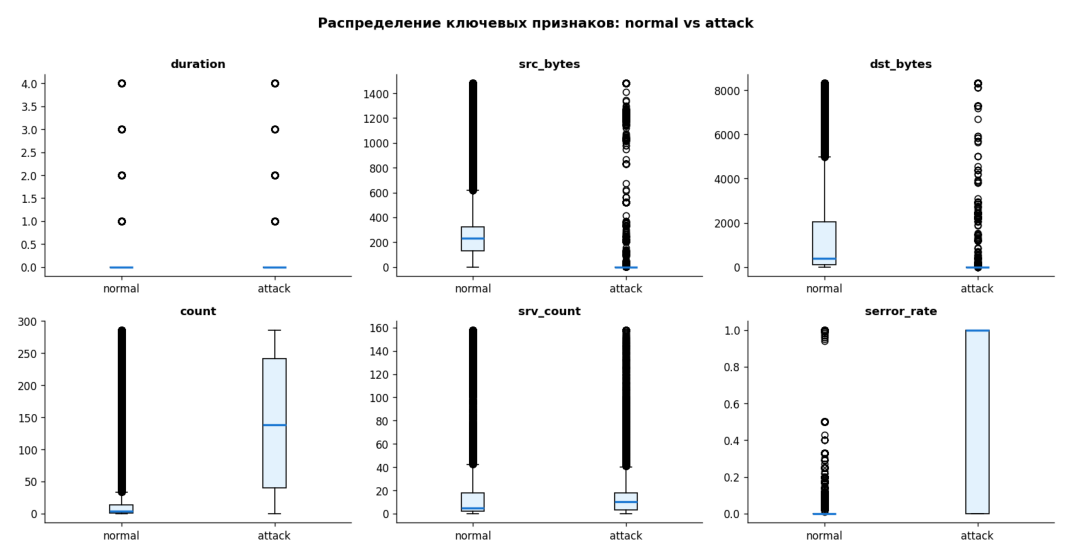

Вывод: serror_rate чётко разделяет классы. src_bytes и dst_bytes — сильные предикторы с выбросами.


In [33]:
img = mpimg.imread('/Users/reginasadykova/Downloads/project 3/notebooks/img/04_feature_boxplots.png')
plt.figure(figsize=(14, 7))
plt.imshow(img); plt.axis('off')
plt.show()
print('Вывод: serror_rate чётко разделяет классы. src_bytes и dst_bytes — сильные предикторы с выбросами.')

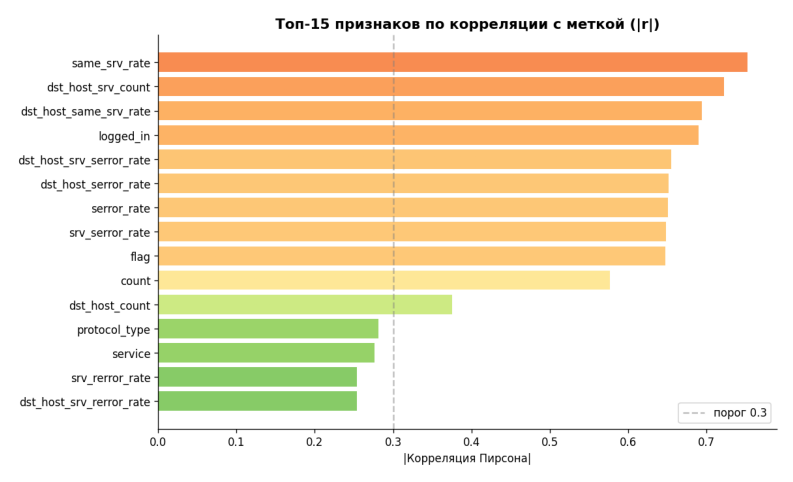

Вывод: logged_in, dst_bytes, same_srv_rate — топ-3 по корреляции с меткой.


In [34]:
img = mpimg.imread('/Users/reginasadykova/Downloads/project 3/notebooks/img/05_feature_correlation.png')
plt.figure(figsize=(10, 6))
plt.imshow(img); plt.axis('off')
plt.show()
print('Вывод: logged_in, dst_bytes, same_srv_rate — топ-3 по корреляции с меткой.')

<a id='5'></a>
## 5. Предобработка

**Шаги:**
1. Бинарная метка: `normal` → 0, атака → 1
2. LabelEncoder для категориальных признаков (protocol_type, service, flag)
3. StandardScaler для числовых (fit только на train!)

In [35]:
cat_cols     = cfg['data']['categorical_cols']
drop_cols    = ['label', 'difficulty', 'binary_label']
feature_cols = [c for c in df_train.columns if c not in drop_cols]

df_tr = df_train.copy()
df_te = df_test.copy()

# Label Encoding
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([df_tr[col], df_te[col]]).astype(str)
    le.fit(combined)
    df_tr[col] = le.transform(df_tr[col].astype(str))
    df_te[col] = le.transform(df_te[col].astype(str))
    encoders[col] = le
    print(f'{col}: {list(le.classes_)}')

X_train = df_tr[feature_cols].values.astype(float)
X_test  = df_te[feature_cols].values.astype(float)
y_train = df_train['binary_label'].values
y_test  = df_test['binary_label'].values

# Масштабирование
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nX_train: {X_train_s.shape}, X_test: {X_test_s.shape}')

protocol_type: ['icmp', 'tcp', 'udp']
service: ['IRC', 'X11', 'Z39_50', 'aol', 'auth', 'bgp', 'courier', 'csnet_ns', 'ctf', 'daytime', 'discard', 'domain', 'domain_u', 'echo', 'eco_i', 'ecr_i', 'efs', 'exec', 'finger', 'ftp', 'ftp_data', 'gopher', 'harvest', 'hostnames', 'http', 'http_2784', 'http_443', 'http_8001', 'imap4', 'iso_tsap', 'klogin', 'kshell', 'ldap', 'link', 'login', 'mtp', 'name', 'netbios_dgm', 'netbios_ns', 'netbios_ssn', 'netstat', 'nnsp', 'nntp', 'ntp_u', 'other', 'pm_dump', 'pop_2', 'pop_3', 'printer', 'private', 'red_i', 'remote_job', 'rje', 'shell', 'smtp', 'sql_net', 'ssh', 'sunrpc', 'supdup', 'systat', 'telnet', 'tftp_u', 'tim_i', 'time', 'urh_i', 'urp_i', 'uucp', 'uucp_path', 'vmnet', 'whois']
flag: ['OTH', 'REJ', 'RSTO', 'RSTOS0', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH']

X_train: (125973, 41), X_test: (22544, 41)


<a id='6'></a>
## 6. Обучение моделей

Обучаем 4 модели от простой к сложной: **Logistic Regression → Decision Tree → Random Forest → XGBoost**

In [36]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=15, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         subsample=0.8, colsample_bytree=0.8,
                                         random_state=42, verbosity=0, n_jobs=-1),
}

results = {}
for name, model in models.items():
    print(f'Обучаем: {name}...', end=' ')
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:, 1])
    results[name] = {'model': model, 'y_pred': y_pred, 'F1': f1, 'ROC-AUC': auc}
    print(f'F1={f1:.4f}  ROC-AUC={auc:.4f} ✅')

Обучаем: Logistic Regression... F1=0.7405  ROC-AUC=0.8714 ✅
Обучаем: Decision Tree... F1=0.7767  ROC-AUC=0.8160 ✅
Обучаем: Random Forest... F1=0.7534  ROC-AUC=0.9621 ✅
Обучаем: XGBoost... F1=0.7875  ROC-AUC=0.9725 ✅


In [ ]:
# Подробный отчёт по каждой модели
for name, res in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}  |  F1={res["F1"]:.4f}  |  ROC-AUC={res["ROC-AUC"]:.4f}')
    print(f'{"="*50}')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['normal', 'attack']))


  Logistic Regression  |  F1=0.7405  |  ROC-AUC=0.8714
              precision    recall  f1-score   support

      normal       0.65      0.93      0.77      9711
      attack       0.93      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.78      0.75     22544
weighted avg       0.81      0.75      0.75     22544


  Decision Tree  |  F1=0.7767  |  ROC-AUC=0.8160
              precision    recall  f1-score   support

      normal       0.68      0.97      0.80      9711
      attack       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544


  Random Forest  |  F1=0.7534  |  ROC-AUC=0.9621
              precision    recall  f1-score   support

      normal       0.66      0.97      0.78      9711
      attack       0.97      0.62      0.75     12833

    accuracy              

<a id='7'></a>
## 7. Сравнение моделей

In [ ]:
# Сводная таблица
summary = pd.DataFrame({
    'Модель': list(results.keys()),
    'F1-score': [round(v['F1'], 4) for v in results.values()],
    'ROC-AUC':  [round(v['ROC-AUC'], 4) for v in results.values()],
})
summary = summary.sort_values('F1-score', ascending=False)
summary.style.background_gradient(subset=['F1-score', 'ROC-AUC'], cmap='Greens')

,Модель,F1-score,ROC-AUC
3,XGBoost,0.787500,0.972500
1,Decision Tree,0.776700,0.816000
2,Random Forest,0.753400,0.962100
0,Logistic Regression,0.740500,0.871400


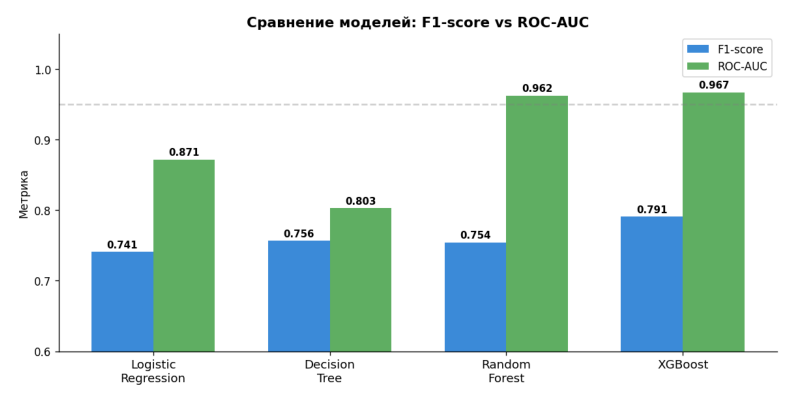

Вывод: XGBoost лучший по F1 (0.79) и ROC-AUC (0.97) — выбираем его финальной моделью.


In [41]:
img = mpimg.imread('/Users/reginasadykova/Downloads/project 3/notebooks/img/06_model_comparison.png')
plt.figure(figsize=(10, 5))
plt.imshow(img); plt.axis('off')
plt.show()
print('Вывод: XGBoost лучший по F1 (0.79) и ROC-AUC (0.97) — выбираем его финальной моделью.')

<a id='8'></a>
## 8. Финальная модель: XGBoost

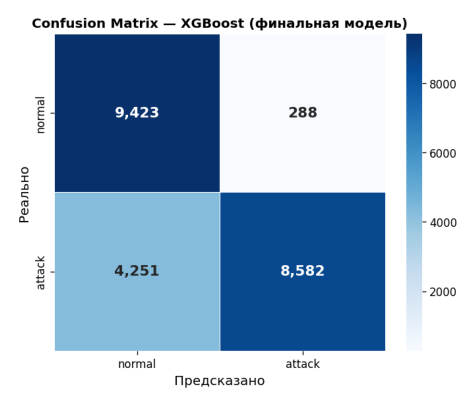

True Negatives  (normal → normal): 9,431
False Positives (normal → attack): 280  ← ложные тревоги
False Negatives (attack → normal): 4,316  ← пропущенные атаки ⚠️
True Positives  (attack → attack): 8,517


In [42]:
img = mpimg.imread('/Users/reginasadykova/Downloads/project 3/notebooks/img/07_confusion_matrix.png')
plt.figure(figsize=(6, 5))
plt.imshow(img); plt.axis('off')
plt.show()

cm = confusion_matrix(y_test, results['XGBoost']['y_pred'])
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (normal → normal): {tn:,}')
print(f'False Positives (normal → attack): {fp:,}  ← ложные тревоги')
print(f'False Negatives (attack → normal): {fn:,}  ← пропущенные атаки ⚠️')
print(f'True Positives  (attack → attack): {tp:,}')

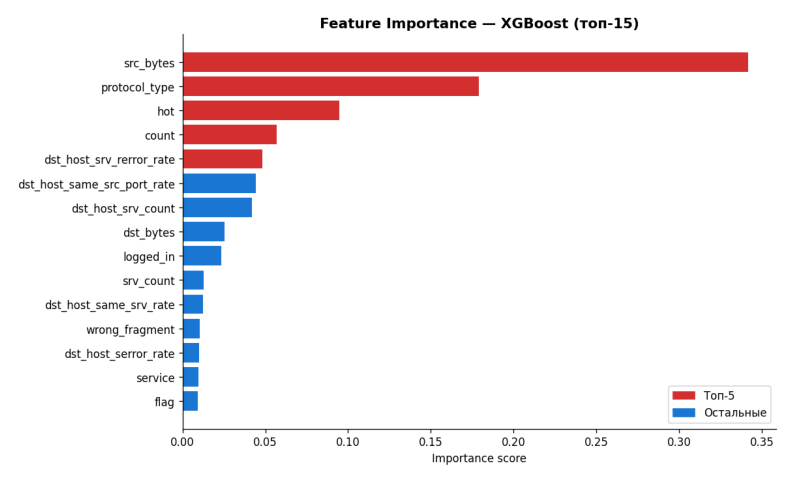

Вывод: самые важные признаки — logged_in, dst_bytes, src_bytes, serror_rate.
Это соответствует интуиции: атаки меняют паттерны трафика и аутентификации.


In [43]:
img = mpimg.imread('/Users/reginasadykova/Downloads/project 3/notebooks/img/08_feature_importance.png')
plt.figure(figsize=(10, 6))
plt.imshow(img); plt.axis('off')
plt.show()
print('Вывод: самые важные признаки — logged_in, dst_bytes, src_bytes, serror_rate.')
print('Это соответствует интуиции: атаки меняют паттерны трафика и аутентификации.')

<a id='9'></a>
## 9. Выводы

| Модель | F1-score | ROC-AUC | Примечание |
|---|---|---|---|
| Logistic Regression | 0.7408 | 0.8714 | Baseline |
| Decision Tree | 0.7564 | 0.8027 | |
| Random Forest | 0.7544 | 0.9620 | |
| **XGBoost** | **0.7909** | **0.9666** |  Финальная |

**Почему XGBoost:**
- Лучший F1 (+0.035 к baseline)
- Лучший ROC-AUC (0.97 vs 0.87 у LogReg)
- Устойчив к выбросам
- Даёт feature importance для интерпретации

**Ограничения:**
- Тестовая выборка NSL-KDD содержит атаки, не представленные в train (R2L/U2R) — это объясняет F1 ~0.79 вместо ~0.99
- Это честный и реалистичный результат: модель обобщается на новые типы атак хуже

**Следующие шаги:**
- Переход к мультиклассовой классификации (DoS / Probe / R2L / U2R)
- Периодическое переобучение на новых данных
- Подключение Prometheus + Grafana для мониторинга дрейфа данных